Risk-Based Decision Model for Maritime Operations

Objective

This project aims to simulate operational decision-making in maritime environments by integrating multiple variables, including weather conditions, vessel characteristics, environmental factors, and operational constraints.

The goal is to develop a structured and data-driven approach to support decisions under uncertainty.

In [2]:
import pandas as pd

In [3]:
import os
print(os.listdir('../data'))

['operational_data.csv']


In [4]:
df = pd.read_csv('../data/operational_data.csv')
df.head()

,vessel_type,weather,urgency,speed,operation_type,wave_height,visibility,cargo_weight,distance
0,Tugboat,Good,Low,12,Maneuver,0.5,High,5,2
1,Tugboat,Bad,High,20,Maneuver,2.5,Low,8,3
2,Supply Boat,Good,High,30,Transport,1.0,High,20,15
3,Supply Boat,Bad,High,35,Transport,3.0,Low,25,20
4,Passenger Boat,Moderate,Low,40,Transport,1.5,Medium,50,30


In [5]:
def decision_system(row):
    if row['weather'] == 'Bad' and row['speed'] > 30:
        return 'Cancel Operation'
    elif row['weather'] == 'Moderate' and row['speed'] > 25:
        return 'Reduce Speed'
    elif row['urgency'] == 'High' and row['weather'] == 'Good':
        return 'Operate with Caution'
    else:
        return 'Operate Normally'

In [6]:
df['decision'] = df.apply(decision_system, axis=1)
df

,vessel_type,weather,urgency,speed,operation_type,wave_height,visibility,cargo_weight,distance,decision
0,Tugboat,Good,Low,12,Maneuver,0.5,High,5,2,Operate Normally
1,Tugboat,Bad,High,20,Maneuver,2.5,Low,8,3,Operate Normally
2,Supply Boat,Good,High,30,Transport,1.0,High,20,15,Operate with Caution
3,Supply Boat,Bad,High,35,Transport,3.0,Low,25,20,Cancel Operation
4,Passenger Boat,Moderate,Low,40,Transport,1.5,Medium,50,30,Reduce Speed
5,Passenger Boat,Bad,Medium,55,Transport,3.5,Low,60,35,Cancel Operation
6,Tugboat,Moderate,Medium,18,Maneuver,1.2,Medium,6,4,Operate Normally
7,Supply Boat,Good,Medium,28,Transport,1.0,High,22,18,Operate Normally
8,Passenger Boat,Bad,High,60,Transport,4.0,Low,70,40,Cancel Operation
9,Tugboat,Good,Low,15,Maneuver,0.6,High,5,3,Operate Normally


In [7]:
df['decision'].value_counts()

decision
Operate Normally        6
Cancel Operation        3
Reduce Speed            2
Operate with Caution    1
Name: count, dtype: int64

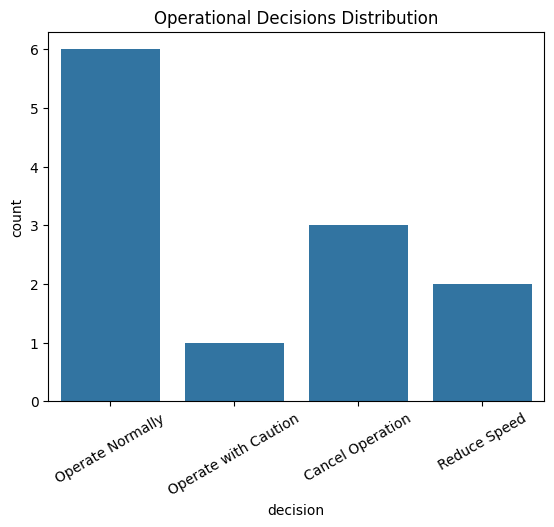

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='decision', data=df)
plt.title('Operational Decisions Distribution')
plt.xticks(rotation=30)
plt.show()

In [9]:
def calculate_risk(row):
    risk = 0

    # Weather
    if row['weather'] == 'Bad':
        risk += 3
    elif row['weather'] == 'Moderate':
        risk += 1

    # Wave height
    if row['wave_height'] > 2.5:
        risk += 3
    elif row['wave_height'] > 1.5:
        risk += 2

    # Visibility
    if row['visibility'] == 'Low':
        risk += 2
    elif row['visibility'] == 'Medium':
        risk += 1

    # Speed
    if row['speed'] > 50:
        risk += 3
    elif row['speed'] > 30:
        risk += 2

    # Cargo weight
    if row['cargo_weight'] > 50:
        risk += 2

    # Distance
    if row['distance'] > 30:
        risk += 2

    # Urgency (reduz risco)
    if row['urgency'] == 'High':
        risk -= 1

    return risk

In [10]:
df['risk_score'] = df.apply(calculate_risk, axis=1)
df.head()

,vessel_type,weather,urgency,speed,operation_type,wave_height,visibility,cargo_weight,distance,decision,risk_score
0,Tugboat,Good,Low,12,Maneuver,0.5,High,5,2,Operate Normally,0
1,Tugboat,Bad,High,20,Maneuver,2.5,Low,8,3,Operate Normally,6
2,Supply Boat,Good,High,30,Transport,1.0,High,20,15,Operate with Caution,-1
3,Supply Boat,Bad,High,35,Transport,3.0,Low,25,20,Cancel Operation,9
4,Passenger Boat,Moderate,Low,40,Transport,1.5,Medium,50,30,Reduce Speed,4


In [11]:
def decision_from_risk(score):
    if score >= 7:
        return 'Cancel Operation'
    elif score >= 4:
        return 'Reduce Speed'
    else:
        return 'Operate Normally'

In [12]:
df['decision'] = df['risk_score'].apply(decision_from_risk)
df

,vessel_type,weather,urgency,speed,operation_type,wave_height,visibility,cargo_weight,distance,decision,risk_score
0,Tugboat,Good,Low,12,Maneuver,0.5,High,5,2,Operate Normally,0
1,Tugboat,Bad,High,20,Maneuver,2.5,Low,8,3,Reduce Speed,6
2,Supply Boat,Good,High,30,Transport,1.0,High,20,15,Operate Normally,-1
3,Supply Boat,Bad,High,35,Transport,3.0,Low,25,20,Cancel Operation,9
4,Passenger Boat,Moderate,Low,40,Transport,1.5,Medium,50,30,Reduce Speed,4
5,Passenger Boat,Bad,Medium,55,Transport,3.5,Low,60,35,Cancel Operation,15
6,Tugboat,Moderate,Medium,18,Maneuver,1.2,Medium,6,4,Operate Normally,2
7,Supply Boat,Good,Medium,28,Transport,1.0,High,22,18,Operate Normally,0
8,Passenger Boat,Bad,High,60,Transport,4.0,Low,70,40,Cancel Operation,14
9,Tugboat,Good,Low,15,Maneuver,0.6,High,5,3,Operate Normally,0


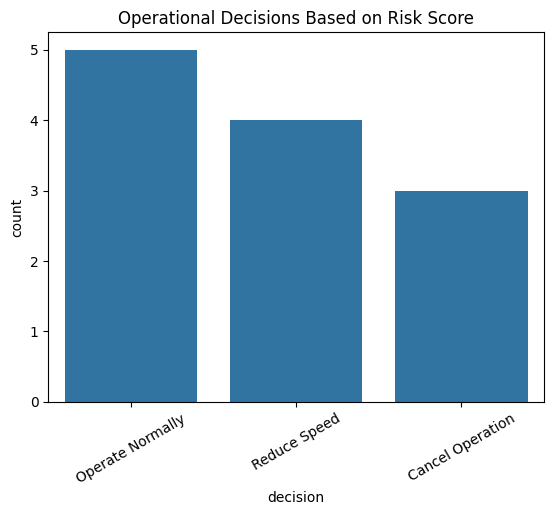

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='decision', data=df)
plt.title('Operational Decisions Based on Risk Score')
plt.xticks(rotation=30)
plt.show()

##  Key Insights

* The risk score approach provides a more realistic representation of operational conditions by integrating multiple variables into a unified framework
* Environmental factors such as adverse weather, high waves, and low visibility are the primary drivers of operational risk
* Operational variables, including vessel speed and distance, significantly amplify risk levels
* Operational urgency influences decision-making but does not eliminate underlying risks


## Conclusion

This project demonstrates how a risk-based approach can enhance decision-making in maritime operations.

By consolidating multiple operational and environmental factors into a single risk score, the model enables more structured, consistent, and transparent decisions, contributing to improved safety and operational efficiency.